---------------------------------------------------------------------------------------------------------------------------------------------

# 🛰️ SatEnergy — Notebook 01: Coleta de Dados

**Objetivo:** Coletar e integrar dados de múltiplas fontes para alimentar o sistema de previsão de geração renovável e score de risco climático.

| Fonte | Dados | Frequência |
|-------|-------|------------|
| ONS | Fator de capacidade solar e eólica por usina | Mensal |
| INPE / GOES-19 | Focos de calor em tempo quase-real | 10 minutos |
| EPE | Linhas de transmissão do SIN | Estático |
| ANEEL SIGEL | Subestações de energia | Estático |


In [65]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import geopandas as gpd
import requests
import json
import zipfile
import re
import warnings

from io import StringIO
from datetime import datetime
from shapely.geometry import Point
from shapely.ops import unary_union
from IPython.display import Image, display

warnings.filterwarnings("ignore")
plt.rcParams['figure.dpi'] = 100

print(f"✅ Bibliotecas carregadas | Pandas {pd.__version__} | NumPy {np.__version__}")

✅ Bibliotecas carregadas | Pandas 3.0.3 | NumPy 2.4.6


## 1. Mapa Base — Contorno do Brasil

In [66]:
url_brasil = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
mundo = gpd.read_file(url_brasil)
brasil = mundo[mundo["name"] == "Brazil"]
brasil_shape = unary_union(brasil.geometry)

print(f"✅ Shapefile do Brasil carregado")

✅ Shapefile do Brasil carregado


## 2. ONS — Fator de Capacidade de Geração Solar e Eólica

**Fonte:** [dados.ons.org.br](https://dados.ons.org.br)  
**Dataset:** Fator de Capacidade de Geração Eólica e Solar  
**Descrição:** Relação entre a geração verificada e a capacidade instalada de usinas solares e eólicas despachadas pelo ONS, em base horária.

In [67]:
import glob

arquivos = glob.glob("../data/raw/FATOR*.csv")
df_ons = pd.read_csv(arquivos[0], sep=";", encoding="utf-8")

print(f"✅ {len(df_ons):,} registros carregados do ONS")
print(f"Período: {df_ons['din_instante'].min()} até {df_ons['din_instante'].max()}")
print(f"Tipos de usina: {df_ons['nom_tipousina'].unique()}")

✅ 166,320 registros carregados do ONS
Período: 2026-04-01 00:00:00 até 2026-04-30 23:00:00
Tipos de usina: <ArrowStringArray>
['Eólica', 'Solar']
Length: 2, dtype: str


In [68]:
df_solar  = df_ons[df_ons["nom_tipousina"] == "Solar"]
df_eolica = df_ons[df_ons["nom_tipousina"] == "Eólica"]

print(f"Usinas Solares:  {len(df_solar):,} registros")
print(f"Usinas Eólicas:  {len(df_eolica):,} registros")
print("\n--- Fator de Capacidade Médio por Subsistema ---")
print(df_ons.groupby(["nom_subsistema", "nom_tipousina"])["val_fatorcapacidade"].mean().round(3))

Usinas Solares:  56,160 registros
Usinas Eólicas:  110,160 registros

--- Fator de Capacidade Médio por Subsistema ---
nom_subsistema        nom_tipousina
Nordeste              Eólica           0.263
                      Solar            0.182
Norte                 Eólica           0.121
Sudeste/Centro-Oeste  Solar            0.203
Sul                   Eólica           0.272
Name: val_fatorcapacidade, dtype: float64


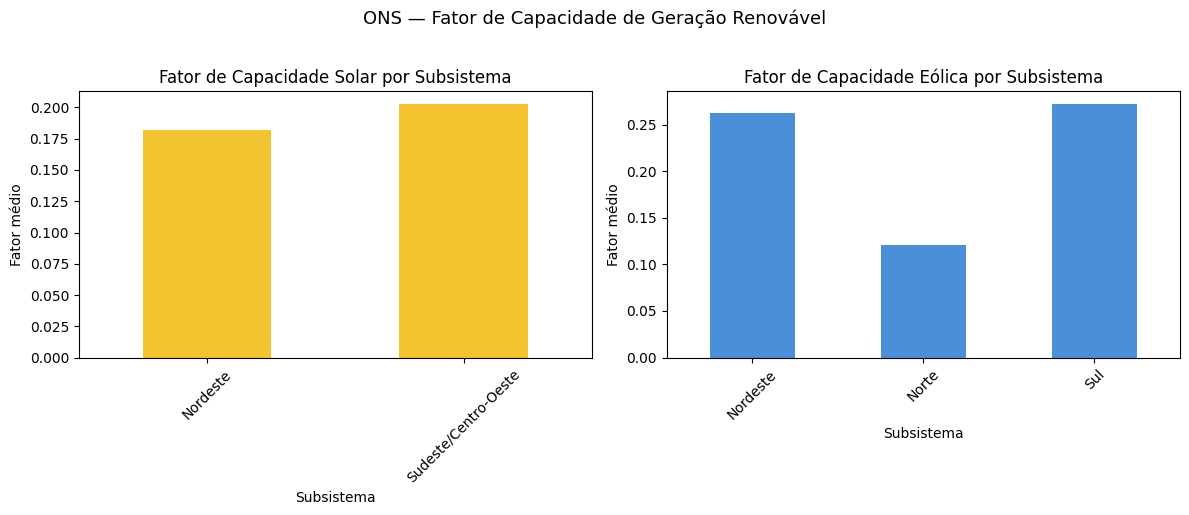

✅ Gráfico salvo


In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_solar.groupby("nom_subsistema")["val_fatorcapacidade"].mean().plot(
    kind="bar", ax=axes[0], color="#f4c430"
)
axes[0].set_title("Fator de Capacidade Solar por Subsistema")
axes[0].set_xlabel("Subsistema")
axes[0].set_ylabel("Fator médio")
axes[0].tick_params(axis="x", rotation=45)

df_eolica.groupby("nom_subsistema")["val_fatorcapacidade"].mean().plot(
    kind="bar", ax=axes[1], color="#4a90d9"
)
axes[1].set_title("Fator de Capacidade Eólica por Subsistema")
axes[1].set_xlabel("Subsistema")
axes[1].set_ylabel("Fator médio")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("ONS — Fator de Capacidade de Geração Renovável", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/grafico_fator_capacidade_ons.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo")

## 3. INPE / GOES-19 — Focos de Calor em Tempo Quase-Real

**Fonte:** [dataserver-coids.inpe.br](https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/10min/)  
**Satélite:** GOES-19  
**Descrição:** Focos de calor detectados por satélite, atualizados a cada 10 minutos. Sem necessidade de autenticação.

In [70]:
URL_INPE = "https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/10min/"

print("🛰️ Conectando ao servidor INPE...")
r = requests.get(URL_INPE, verify=False, timeout=15)
arquivos_csv = re.findall(r'href="(focos_[^"]+\.csv)"', r.text)
print(f"✅ {len(arquivos_csv)} arquivos disponíveis | Último: {arquivos_csv[-1]}")

# Baixa os últimos 18 arquivos (3 horas)
dfs = []
for arquivo in arquivos_csv[-18:]:
    r_csv = requests.get(f"{URL_INPE}{arquivo}", verify=False, timeout=15)
    df_temp = pd.read_csv(StringIO(r_csv.text))
    if len(df_temp) > 0:
        dfs.append(df_temp)

df_focos = pd.concat(dfs, ignore_index=True)

# Filtra focos dentro do Brasil e remove duplicatas
geometry = [Point(xy) for xy in zip(df_focos["lon"], df_focos["lat"])]
gdf_todos = gpd.GeoDataFrame(df_focos, geometry=geometry, crs="EPSG:4326")
gdf_todos["dentro_brasil"] = gdf_todos.geometry.within(brasil_shape)
df_focos_brasil = gdf_todos[gdf_todos["dentro_brasil"]].drop_duplicates(subset=["lat", "lon"]).reset_index(drop=True)

print(f"\n📊 Focos brutos coletados:  {len(df_focos):,}")
print(f"📍 Focos únicos no Brasil:  {len(df_focos_brasil):,}")
print(f"🕐 Período:                 últimas 3 horas")

🛰️ Conectando ao servidor INPE...
✅ 496 arquivos disponíveis | Último: focos_10min_20260528_1300.csv

📊 Focos brutos coletados:  26
📍 Focos únicos no Brasil:  2
🕐 Período:                 últimas 3 horas


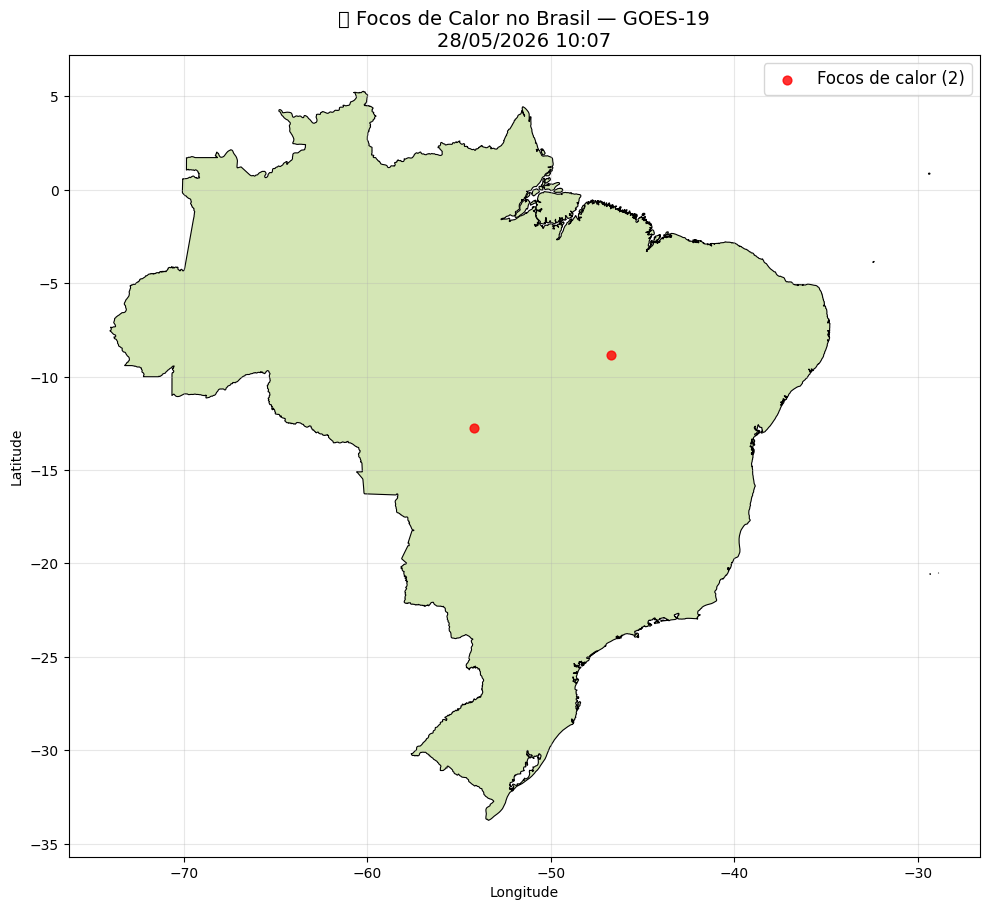

✅ Mapa salvo


In [71]:
# Mapa de focos no Brasil
agora = datetime.now().strftime("%d/%m/%Y %H:%M")

fig, ax = plt.subplots(figsize=(10, 12))
brasil.plot(ax=ax, color="#d4e6b5", edgecolor="black", linewidth=0.8)
df_focos_brasil.plot(ax=ax, color="red", markersize=40, alpha=0.8, label=f"Focos de calor ({len(df_focos_brasil)})")

ax.set_title(f"🔥 Focos de Calor no Brasil — GOES-19\n{agora}", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/mapa_focos_calor.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Mapa salvo")

## 4. Infraestrutura Energética — EPE e ANEEL

**Fontes:**
- **EPE (KMZ):** Linhas de transmissão do SIN — 2.316 linhas com tensão, extensão e concessionária
- **ANEEL SIGEL:** Subestações de energia — 718 subestações

In [72]:
# Linhas de transmissão EPE (KMZ)
kmz_path = "../data/raw/[EPE] Linhas de Transmissão.kmz"

with zipfile.ZipFile(kmz_path, 'r') as kmz:
    for arquivo in kmz.namelist():
        if arquivo.endswith('.kml'):
            kmz.extract(arquivo, "../data/raw/")

gdf_lt_epe = gpd.read_file("../data/raw/doc.kml")
gdf_lt_epe["Tens__o__kV_"] = pd.to_numeric(gdf_lt_epe["Tens__o__kV_"], errors="coerce")

def extrair_subestacoes(nome_linha):
    match = re.search(r'LT \d+ kV (.+?) [-–] (.+?)(?:,|$)', str(nome_linha))
    if match:
        return match.group(1).strip(), match.group(2).strip().split(',')[0].strip()
    return "Desconhecida", "Desconhecida"

gdf_lt_epe[["sub_origem", "sub_destino"]] = gdf_lt_epe["Nome"].apply(
    lambda x: pd.Series(extrair_subestacoes(x))
)

print(f"✅ {len(gdf_lt_epe):,} linhas de transmissão carregadas (EPE)")

✅ 2,316 linhas de transmissão carregadas (EPE)


In [73]:
# Subestações ANEEL SIGEL
BASE_URL_ANEEL = "https://sigel.aneel.gov.br/arcgis/rest/services/Web_Layer_UFV_Outras_Bases/MapServer"
gdfs = {}

url = f"{BASE_URL_ANEEL}/24/query?where=1%3D1&outFields=*&f=geojson"
r = requests.get(url, verify=False, timeout=60)
dados = json.loads(r.text)
features = dados.get("features", [])
if features:
    gdf = gpd.GeoDataFrame.from_features(features)
    gdf.set_crs("EPSG:4326", inplace=True, allow_override=True)
    gdfs["Subestações"] = gdf
    print(f"✅ Subestações: {len(gdf):,} registros")

gdfs["Subestações"]["centroide"] = gdfs["Subestações"].geometry.centroid
gdf_sub_centroides = gpd.GeoDataFrame(gdfs["Subestações"], geometry="centroide", crs="EPSG:4326")

✅ Subestações: 718 registros


## 5. Sistema de Alertas — Score de Risco Climático

**Metodologia:**  
Para cada foco de calor detectado pelo GOES-19, calcula-se a distância em km até a linha de transmissão mais próxima. O risco é classificado em 4 níveis:

| Nível | Distância | Significado |
|-------|-----------|-------------|
| 🔴 Crítico | ≤ 10 km | Ameaça imediata à infraestrutura |
| 🟠 Alto | ≤ 50 km | Risco elevado de propagação |
| 🟡 Médio | ≤ 100 km | Monitoramento necessário |
| 🟢 Baixo | > 100 km | Sem risco imediato |

In [74]:
# Reprojetando para sistema métrico (SIRGAS 2000 / UTM zona 23S)
gdf_focos_proj = df_focos_brasil.to_crs("EPSG:31983")
gdf_lt_proj    = gdf_lt_epe.to_crs("EPSG:31983")

def linha_mais_proxima(ponto):
    distancias = gdf_lt_proj.geometry.distance(ponto)
    idx = distancias.idxmin()
    return pd.Series({
        "dist_linha_km":   distancias[idx] / 1000,
        "linha_nome":      gdf_lt_epe.loc[idx, "Nome"],
        "linha_tensao_kv": gdf_lt_epe.loc[idx, "Tens__o__kV_"],
        "sub_origem":      gdf_lt_epe.loc[idx, "sub_origem"],
        "sub_destino":     gdf_lt_epe.loc[idx, "sub_destino"],
        "concessionaria":  gdf_lt_epe.loc[idx, "Concess__o"],
    })

print("⏳ Calculando distâncias... (~1 min)")
df_linhas = gdf_focos_proj.geometry.apply(linha_mais_proxima)

gdf_focos_proj = pd.concat([
    gdf_focos_proj.reset_index(drop=True),
    df_linhas.reset_index(drop=True)
], axis=1)

def classificar_risco(dist):
    if dist <= 10:    return "🔴 CRÍTICO"
    elif dist <= 50:  return "🟠 ALTO"
    elif dist <= 100: return "🟡 MÉDIO"
    else:             return "🟢 BAIXO"

gdf_focos_proj["risco"] = gdf_focos_proj["dist_linha_km"].apply(classificar_risco)
print("✅ Cálculo concluído!")

⏳ Calculando distâncias... (~1 min)
✅ Cálculo concluído!


In [75]:
# Tabela de alertas
agora = datetime.now().strftime("%d/%m/%Y %H:%M")

print("=" * 90)
print(f"🚨 SISTEMA DE ALERTAS SATENERGY — {agora}")
print("=" * 90)
print(f"\nTotal de focos analisados: {len(gdf_focos_proj)}")
print(f"\nDistribuição de risco:")
print(gdf_focos_proj["risco"].value_counts())

cols = ["lat", "lon", "dist_linha_km", "linha_nome", "linha_tensao_kv", "sub_origem", "sub_destino", "concessionaria", "risco"]
df_alertas = gdf_focos_proj[cols].copy().sort_values("dist_linha_km").head(15).round(2)
df_alertas.columns = ["Lat", "Lon", "Dist (km)", "Linha", "Tensão (kV)", "Sub Origem", "Sub Destino", "Concessionária", "Risco"]

print(f"\nTop 15 focos mais críticos:")
print(df_alertas.to_string(index=False))

df_alertas.to_csv("../data/processed/alertas_risco.csv", index=False, encoding="utf-8-sig")
print("\n✅ Alertas salvos em data/processed/alertas_risco.csv")

🚨 SISTEMA DE ALERTAS SATENERGY — 28/05/2026 10:08

Total de focos analisados: 2

Distribuição de risco:
risco
🔴 CRÍTICO    1
🟢 BAIXO      1
Name: count, dtype: int64

Top 15 focos mais críticos:
   Lat   Lon  Dist (km)                               Linha  Tensão (kV)   Sub Origem Sub Destino                                            Concessionária     Risco
 -8.85 -46.7       0.32   LT 800 kV Graça Aranha – Silvânia        800.0 Graça Aranha    Silvânia                                                       NaN 🔴 CRÍTICO
-12.73 -54.2     110.49 LT 500 kV Cláudia - Paranatinga, C3        500.0      Cláudia Paranatinga Prte - Paranaíta Ribeirãozinho Transmissora De Energia Sa   🟢 BAIXO

✅ Alertas salvos em data/processed/alertas_risco.csv


## 6. Mapa — Score de Risco Climático

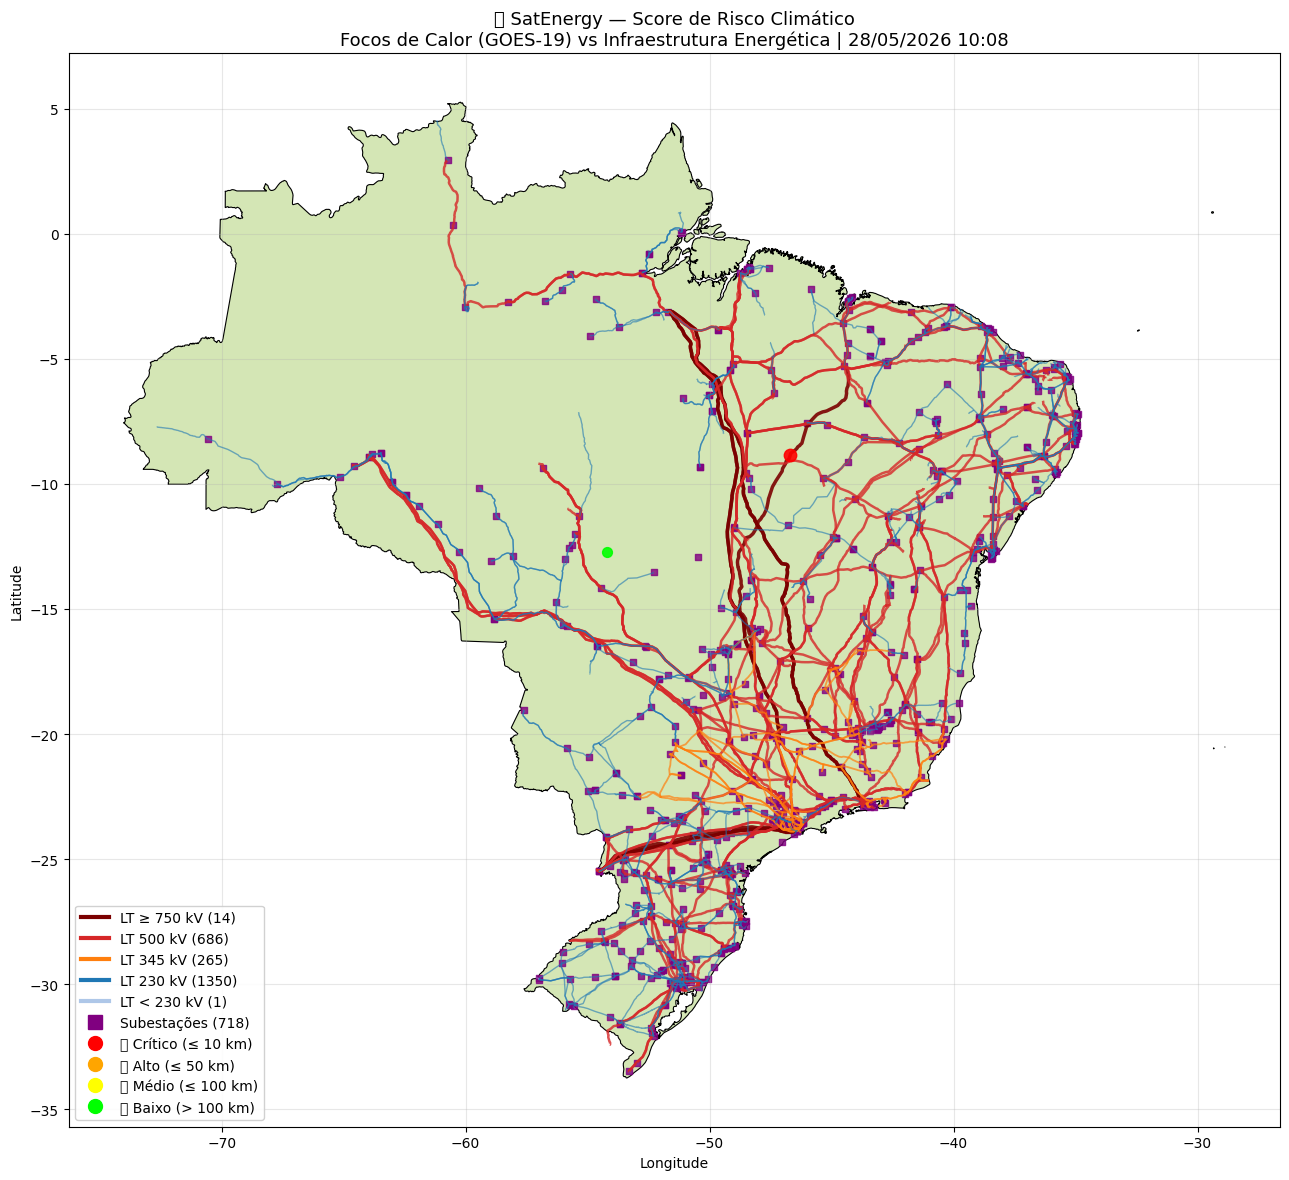

✅ Mapa salvo em data/processed/mapa_score_risco.png


In [76]:
lt_750   = gdf_lt_epe[gdf_lt_epe["Tens__o__kV_"] >= 750]
lt_500   = gdf_lt_epe[(gdf_lt_epe["Tens__o__kV_"] >= 500) & (gdf_lt_epe["Tens__o__kV_"] < 750)]
lt_345   = gdf_lt_epe[(gdf_lt_epe["Tens__o__kV_"] >= 345) & (gdf_lt_epe["Tens__o__kV_"] < 500)]
lt_230   = gdf_lt_epe[(gdf_lt_epe["Tens__o__kV_"] >= 230) & (gdf_lt_epe["Tens__o__kV_"] < 345)]
lt_baixa = gdf_lt_epe[gdf_lt_epe["Tens__o__kV_"] < 230]

fig, ax = plt.subplots(figsize=(13, 15))

brasil.plot(ax=ax, color="#d4e6b5", edgecolor="black", linewidth=0.8)

if len(lt_750)   > 0: lt_750.plot(ax=ax,   color="#7b0000", linewidth=2.5, alpha=0.9)
if len(lt_500)   > 0: lt_500.plot(ax=ax,   color="#d62728", linewidth=1.8, alpha=0.8)
if len(lt_345)   > 0: lt_345.plot(ax=ax,   color="#ff7f0e", linewidth=1.3, alpha=0.7)
if len(lt_230)   > 0: lt_230.plot(ax=ax,   color="#1f77b4", linewidth=1.0, alpha=0.6)
if len(lt_baixa) > 0: lt_baixa.plot(ax=ax, color="#aec7e8", linewidth=0.7, alpha=0.5)

gdf_sub_centroides.plot(ax=ax, color="purple", markersize=25, alpha=0.8, marker="s")

cores_risco = {
    "🔴 CRÍTICO": ("red",    80),
    "🟠 ALTO":    ("orange", 70),
    "🟡 MÉDIO":   ("yellow", 60),
    "🟢 BAIXO":   ("lime",   50),
}
for nivel, (cor, tam) in cores_risco.items():
    subset = gdf_focos_proj[gdf_focos_proj["risco"] == nivel]
    if len(subset) > 0:
        gpd.GeoDataFrame(subset, geometry="geometry", crs="EPSG:31983").to_crs("EPSG:4326").plot(
            ax=ax, color=cor, markersize=tam, alpha=0.9, marker="o", zorder=5
        )

legenda = [
    mlines.Line2D([], [], color="#7b0000", linewidth=3, label=f"LT ≥ 750 kV ({len(lt_750)})"),
    mlines.Line2D([], [], color="#d62728", linewidth=3, label=f"LT 500 kV ({len(lt_500)})"),
    mlines.Line2D([], [], color="#ff7f0e", linewidth=3, label=f"LT 345 kV ({len(lt_345)})"),
    mlines.Line2D([], [], color="#1f77b4", linewidth=3, label=f"LT 230 kV ({len(lt_230)})"),
    mlines.Line2D([], [], color="#aec7e8", linewidth=3, label=f"LT < 230 kV ({len(lt_baixa)})"),
    mlines.Line2D([], [], color="purple", marker="s", markersize=10, linestyle="None", label=f"Subestações ({len(gdf_sub_centroides)})"),
    mlines.Line2D([], [], color="red",    marker="o", markersize=10, linestyle="None", label="🔴 Crítico (≤ 10 km)"),
    mlines.Line2D([], [], color="orange", marker="o", markersize=10, linestyle="None", label="🟠 Alto (≤ 50 km)"),
    mlines.Line2D([], [], color="yellow", marker="o", markersize=10, linestyle="None", label="🟡 Médio (≤ 100 km)"),
    mlines.Line2D([], [], color="lime",   marker="o", markersize=10, linestyle="None", label="🟢 Baixo (> 100 km)"),
]

ax.legend(handles=legenda, fontsize=10, loc="lower left", framealpha=0.9)
ax.set_title(f"🚨 SatEnergy — Score de Risco Climático\nFocos de Calor (GOES-19) vs Infraestrutura Energética | {agora}", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/mapa_score_risco.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Mapa salvo em data/processed/mapa_score_risco.png")